In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Step 1: Load model_df

In [76]:
model_df = pd.read_csv("../data/processed/model_clustered.csv")

In [77]:
model_df.columns

Index(['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city',
       'signup_date', 'age', 'gender', 'total_trips', 'cancelled_trips',
       'days_since_last_trip', 'churned', 'engagement_score', 'loyalty_score',
       'persona', 'signup_channel', 'income_level', 'payment_method',
       'device_type', 'trips_30d', 'completed_trips_30d',
       'cancelled_trips_30d', 'total_fare_30d', 'avg_fare_30d',
       'total_distance_30d', 'avg_duration_30d', 'promo_used_trips_30d',
       'last_trip_date', 'recency_days', 'app_open', 'ride_completed',
       'ride_request', 'search', 'total_events_30d', 'promos_redeemed_30d',
       'promo_cost_30d', 'avg_discount_value_30d', 'Cluster'],
      dtype='object')

In [78]:
model_df.shape

(3000, 39)

## Step 2: Select final features

In [79]:
# X and Y
features = model_df.drop(['customer_id', 'first_name', 'last_name', 'email', 'phone', 'signup_date',
                          'cancelled_trips', 'churned', 'engagement_score', 'loyalty_score', 'payment_method',
                          'device_type', 'avg_fare_30d', 'avg_duration_30d', 'last_trip_date', 'recency_days', 
                          'app_open', 'ride_completed','ride_request', 'search','promos_redeemed_30d',
                          'promo_cost_30d', 'avg_discount_value_30d',], axis=1)
target = model_df['churned']

## Step 3: Preprocessing

#### Step 3a: Encode Categorical Features

In [80]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [81]:
# Label encoding for binary categories
le = LabelEncoder()
features['gender'] = le.fit_transform(features['gender'])

# One-hot encoding for multi-class categorical variables
features = pd.get_dummies(features,
    columns=[
        "city",
        "income_level",
        "signup_channel",
        "persona",
        "Cluster"
    ],
    drop_first=True, dtype=int
)

##### Step 3a1: Create correlation heatmap

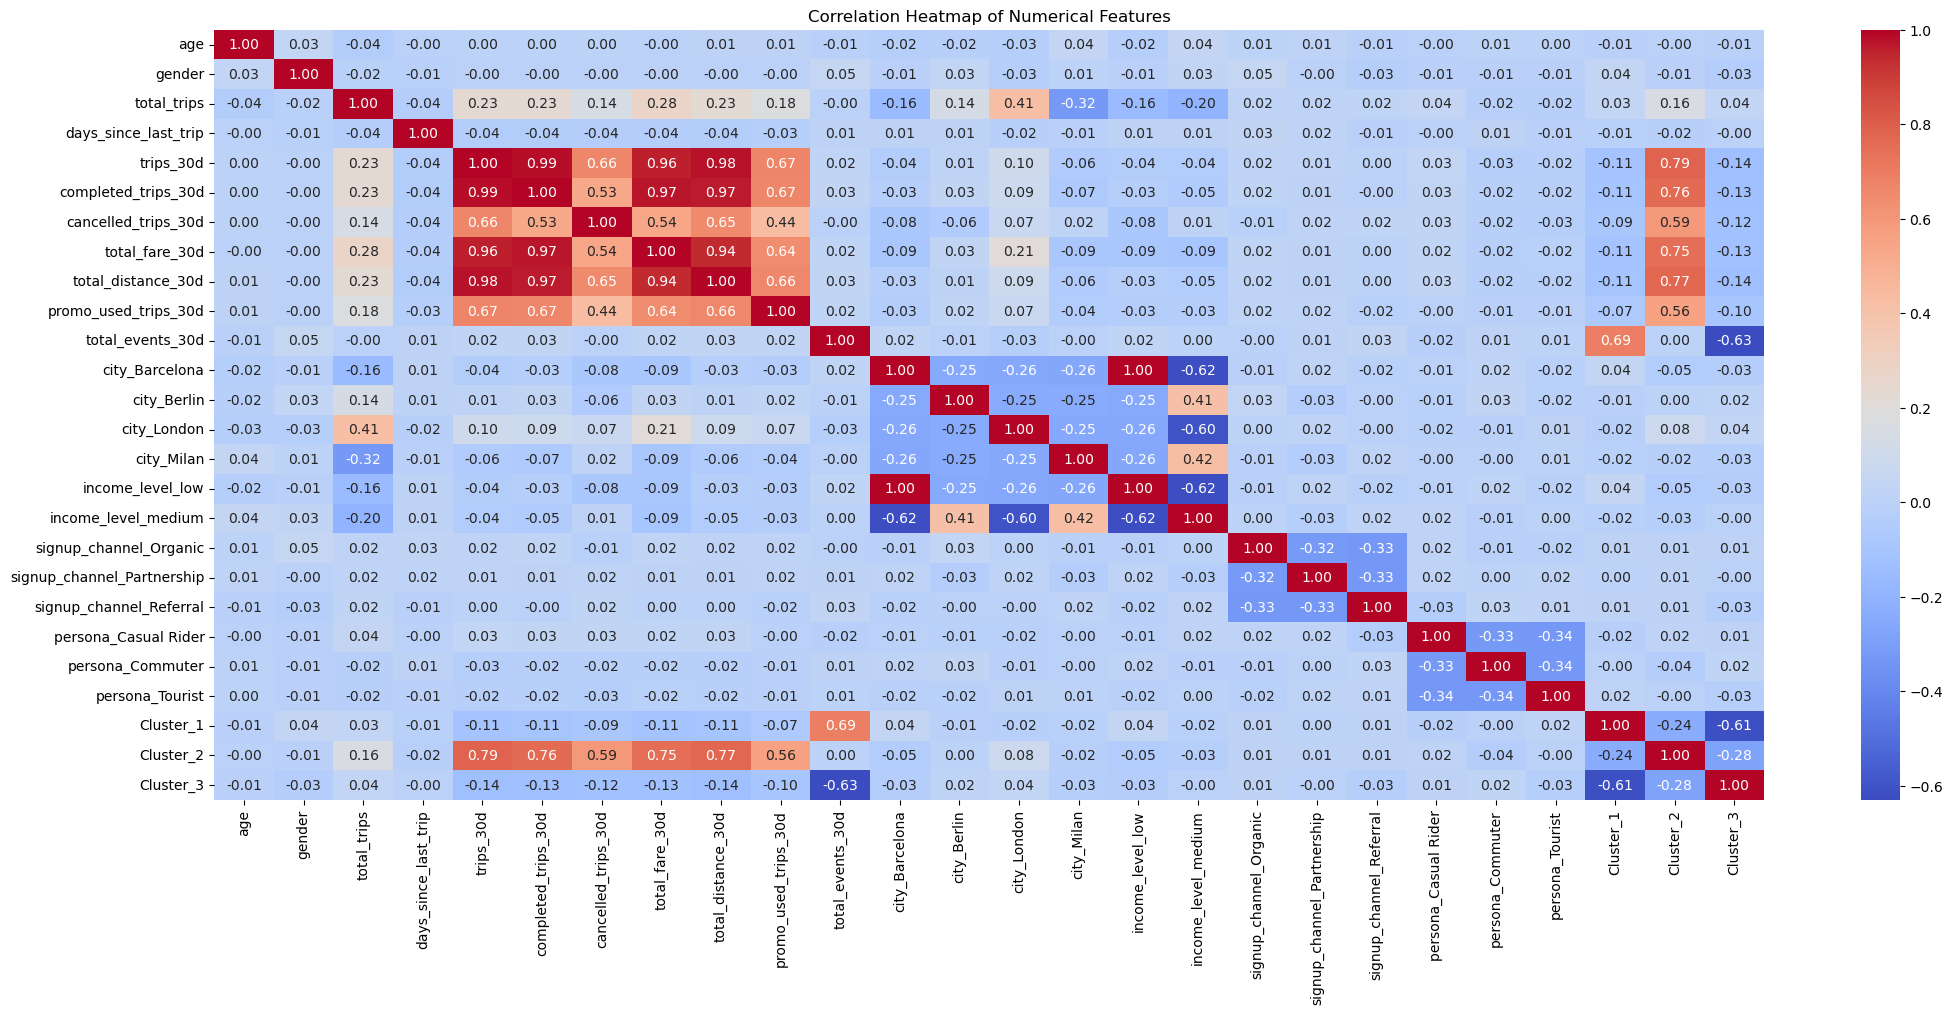

In [82]:
# Correlation matrix
corr_matrix = features.corr()

# Plot correlation heatmap

plt.figure(figsize=(25,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [83]:
features.shape

(3000, 26)

##### Step 3a2: Check correlation with target

In [84]:
# Select numeric features only
numeric_df = features.select_dtypes(include="number")

# Compute correlation with target Series
corr_with_target = (
    numeric_df
        .corrwith(target)
        .dropna()                          # safety: drop NaNs
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={
            "index": "feature",
            0: "correlation"
        })
)

# View top correlated features
corr_with_target.head(28)

,feature,correlation
0,days_since_last_trip,0.193262
1,income_level_medium,0.056690
2,signup_channel_Organic,0.036218
3,Cluster_2,0.026100
4,city_Berlin,0.019753
5,persona_Commuter,0.019659
6,total_fare_30d,0.009610
7,city_Milan,0.009360
8,cancelled_trips_30d,0.008410
9,promo_used_trips_30d,0.006549


#### Step 3b: Scaling numerical features

In [85]:
from sklearn.preprocessing import RobustScaler

In [86]:
scaler = RobustScaler()
num_cols_to_scale = ['age', 'total_trips', 'days_since_last_trip',
       'trips_30d','completed_trips_30d', 'cancelled_trips_30d', 'total_fare_30d',
       'total_distance_30d', 'promo_used_trips_30d', 'total_events_30d']
features[num_cols_to_scale] = scaler.fit_transform(features[num_cols_to_scale])

###### check class distribution

In [87]:
target.value_counts()

churned
0    2451
1     549
Name: count, dtype: int64

In [88]:
target.value_counts(normalize=True)*100

churned
0    81.7
1    18.3
Name: proportion, dtype: float64

<Axes: xlabel='churned', ylabel='count'>

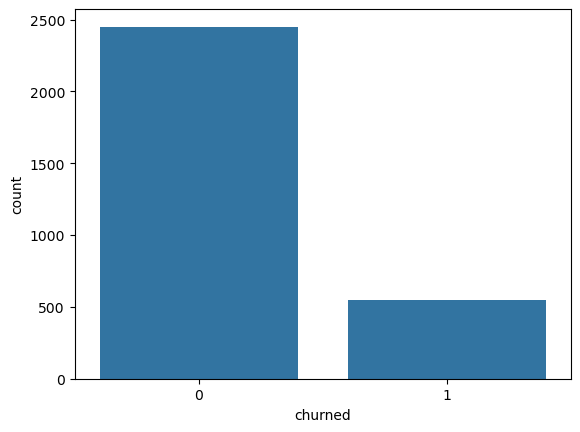

In [89]:
sns.countplot(x=target, data=model_df)

## Step 4: Handling Class Imbalance
##### Step 4a: Oversambling with SMOTE


In [90]:
from imblearn.over_sampling import SMOTE

# Seperate features and target
X = features
y = target

# Apply SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

y_resampled.value_counts()

churned
0    2451
1    2451
Name: count, dtype: int64

##### Step 4b: Convert the cleaned data back to dataframe

In [91]:
resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
resampled_df.head(3)

,age,gender,total_trips,days_since_last_trip,trips_30d,completed_trips_30d,cancelled_trips_30d,total_fare_30d,total_distance_30d,promo_used_trips_30d,...,income_level_medium,signup_channel_Organic,signup_channel_Partnership,signup_channel_Referral,persona_Casual Rider,persona_Commuter,persona_Tourist,Cluster_1,Cluster_2,Cluster_3
0,-0.923077,2,1.157895,0.208333,0.25,0.333333,0.0,0.194435,1.363937e-16,0.0,...,0,0,0,0,0,0,1,0,0,1
1,0.692308,2,0.578947,1.208333,-0.50,-0.666667,0.0,-0.605708,-6.488147e-01,0.0,...,0,0,1,0,0,0,0,0,0,0
2,-0.461538,1,0.315789,-0.458333,0.50,0.333333,1.0,0.539812,5.117574e-01,1.0,...,0,0,0,0,0,0,0,0,0,1


##### Step 4c: saved the resampled X and y

In [92]:
# Save
X_resampled.to_csv("../data/processed/X_resampled.csv", index=False)
y_resampled.to_csv("../data/processed/y_resampled.csv", index=False)

print(f"X_resampled: successfully saved")
print(f"y_resampled: successfully saved")

X_resampled: successfully saved
y_resampled: successfully saved


In [93]:
resampled_df["churned"] = y_resampled
resampled_df.head(3)

,age,gender,total_trips,days_since_last_trip,trips_30d,completed_trips_30d,cancelled_trips_30d,total_fare_30d,total_distance_30d,promo_used_trips_30d,...,signup_channel_Organic,signup_channel_Partnership,signup_channel_Referral,persona_Casual Rider,persona_Commuter,persona_Tourist,Cluster_1,Cluster_2,Cluster_3,churned
0,-0.923077,2,1.157895,0.208333,0.25,0.333333,0.0,0.194435,1.363937e-16,0.0,...,0,0,0,0,0,1,0,0,1,0
1,0.692308,2,0.578947,1.208333,-0.50,-0.666667,0.0,-0.605708,-6.488147e-01,0.0,...,0,1,0,0,0,0,0,0,0,0
2,-0.461538,1,0.315789,-0.458333,0.50,0.333333,1.0,0.539812,5.117574e-01,1.0,...,0,0,0,0,0,0,0,0,1,0


##### Step 5c: save resampled data

In [94]:
resampled_df.to_csv('../data/processed/cleaned_churn_balanced.csv', index=False)

## Step 6: Data splitting

In [95]:
from sklearn.model_selection import train_test_split

# Split the dataset (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 3431
Testing set size: 1471


In [96]:
# Proportion of Train set distribution
y_train.value_counts(normalize=True)*100

churned
1    50.539201
0    49.460799
Name: proportion, dtype: float64

In [97]:
# Proportion of Test set distribution
y_test.value_counts(normalize=True)*100

churned
0    51.257648
1    48.742352
Name: proportion, dtype: float64

## Step 7: Model selection
##### Step 7a: Logistic Regression

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, precision_score

In [99]:
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_probability = logreg.predict_proba(X_test)[:, 1] # probability of class 1 (will churn)

auc = roc_auc_score(y_test, y_probability)
f1 = f1_score(y_test, y_pred)

top_15 = int(0.15 * len(y_test))
top_idx = np.argsort(y_probability)[-top_15:]
precision_15 = precision_score(y_test.iloc[top_idx], np.ones(top_15))

print("Logistic Regression")
print(f"ROC-AUC: {auc:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"Precision@15%: {precision_15:.3f}")


Logistic Regression
ROC-AUC: 0.784
F1-score: 0.701
Precision@15%: 0.891


##### Insight
The Logistic Regression model shows limited ability to rank and identify churners, making it suitable only as a baseline and not reliable enough for precise or high-value retention targeting.

##### Step 6b: Random Forest

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score

In [101]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_probability = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_probability)
f1 = f1_score(y_test, y_pred)

top_15 = int(0.15 * len(y_test))
top_idx = np.argsort(y_probability)[-top_15:]
precision_15 = precision_score(y_test.iloc[top_idx], np.ones(top_15))

print("\nRandom Forest")
print(f"ROC-AUC: {auc:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"Precision@15%: {precision_15:.3f}")



Random Forest
ROC-AUC: 0.902
F1-score: 0.820
Precision@15%: 0.986


##### Insight
The Random Forest model demonstrates excellent predictive performance, with strong ranking ability (ROC-AUC 0.95) and highly effective churn targeting. All customers identified in the top 15% risk segment are true churners, making the model well-suited for cost-efficient retention strategies.

##### Step 6c: Xgboost

In [102]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score

In [103]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_probability = xgb.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_probability)
f1 = f1_score(y_test, y_pred)

top_15 = int(0.15 * len(y_test))
top_idx = np.argsort(y_probability)[-top_15:]
precision_15 = precision_score(y_test.iloc[top_idx], np.ones(top_15))

print("\nXGBoost")
print(f"ROC-AUC: {auc:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"Precision@15%: {precision_15:.3f}")


c:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:02:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
ROC-AUC: 0.926
F1-score: 0.854
Precision@15%: 1.000


##### Step 6d: Tunned xgboost

In [104]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "learning_rate": [0.01, 0.05, 0.1]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train) 

best_model = search.best_estimator_

#print(f"Best params: {search.best_params_}")
#print(f"Best score: {search.best_score_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:02:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [105]:
# Predict probabilities on ORIGINAL test set
y_prob = best_model.predict_proba(X_test)[:, 1]
# Metrics
auc = roc_auc_score(y_test, y_prob)
y_pred = (y_prob >= 0.5).astype(int)
f1 = f1_score(y_test, y_pred)

top_15 = int(0.15 * len(y_test))
top_idx = np.argsort(y_prob)[-top_15:]
precision_15 = precision_score(y_test.iloc[top_idx], np.ones(top_15))

print("\nTunedXGBoost")
print(f"ROC-AUC: {auc:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"Precision@15%: {precision_15:.3f}")




TunedXGBoost
ROC-AUC: 0.921
F1-score: 0.853
Precision@15%: 1.000


##### Insight
The XGBoost model delivers excellent churn prediction performance, accurately ranking customers by risk and perfectly identifying churners within the top 15% highest-risk group, making it highly effective for targeted retention actions.

##### After tuning
The base XGBoost model already demonstrated excellent churn prediction performance, achieving strong ranking ability and perfect precision within the top 15% highest-risk customers. Hyperparameter tuning did not materially improve top-segment targeting performance, indicating that the base model was already near optimal for this use case. Tuning primarily served to validate model robustness rather than to drive significant performance gains.

######

## Step 7: Save models

In [106]:
import pickle
import os
import joblib

In [107]:
path = "../models/artifacts"
os.makedirs(path, exist_ok=True)

with open(f'{path}/logreg_model.pkl', 'wb') as logreg_model_file:
    pickle.dump(logreg, logreg_model_file)

with open(f'{path}/rf_model.pkl', 'wb') as rf_model_file:
    pickle.dump(rf, rf_model_file)

with open(f'{path}/xgb_model.pkl', 'wb') as xgb_model_file:
    pickle.dump(xgb, xgb_model_file)

joblib.dump(best_model, f"{path}/tuned_xgboost_model.pkl")


path = "../models/churn_prep_artifacts"
os.makedirs(path, exist_ok=True)

with open(f'{path}/le_encoder.pkl', 'wb') as le_encoder_file:
    pickle.dump(le, le_encoder_file)

with open(f'{path}/dummy_columns.pkl', 'wb') as dummy_columns_file:
    pickle.dump(features, dummy_columns_file)

with open(f'{path}/scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

with open(f'{path}/smote.pkl', 'wb') as smote_file:
    pickle.dump(smote, smote_file)

##### verify if my model was saved

In [108]:
print(hasattr(logreg, "coef_"))
print(hasattr(rf, "feature_importances_"))
print(hasattr(xgb, "feature_importances_"))

True
True
True
